In [26]:
import os, pickle

from physics.simulation import msq, sample
from physics.hzz import zpair, zz4l
from datasets import balanced
from models import carl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist

import torch
from torch.utils.data import DataLoader, TensorDataset
from lightning import Trainer

In [28]:
OUTPUT_DIR = 'jobs/carl/refactor-one-500k'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '..'

checkpoint_epoch = 45
checkpoint_loss = 0.45

CHECKPOINT = f'checkpoint-alice-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

VERSION = 0
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_1 = msq.Component.SIG
COMPONENT_2 = msq.Component.BKG

SAMPLE_SIZE = 50000
BATCH_SIZE = 32
SEED = 42

In [3]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [4]:
sample_signal = sample.from_csv(cross_section=xs[COMPONENT_1], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_1]), n_rows=int(SAMPLE_SIZE*1.2))
sample_background = sample.from_csv(cross_section=xs[COMPONENT_2], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_2]), n_rows=int(SAMPLE_SIZE*1.2))
        
z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

sample_sig_processed = sample_signal.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]
sample_bkg_processed = sample_background.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

# Get only required features
X_sig = sample_sig_processed.kinematics[features].to_numpy()
X_bkg = sample_bkg_processed.kinematics[features].to_numpy()

X = np.concatenate([X_sig, X_bkg], axis=0)

with open(os.path.join(OUTPUT_DIR, SCALER_FILE), 'rb') as f:
    scaler = pickle.load(f)

X = torch.tensor(scaler.transform(X), dtype=torch.float32)

ratios_sig = (sample_sig_processed.probabilities/sample_sig_processed.reweight(COMPONENT_2, COMPONENT_1).probabilities).to_numpy()
ratios_bkg = (sample_bkg_processed.reweight(COMPONENT_1, COMPONENT_2).probabilities/sample_bkg_processed.probabilities).to_numpy()

ratios = torch.cat((torch.tensor(ratios_sig, dtype=torch.float32), torch.tensor(ratios_bkg, dtype=torch.float32)))

dataset = TensorDataset(X, ratios)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

0.030183487600536626
0.33582737232492404


In [5]:
print(dataset.tensors[0].shape)

torch.Size([100000, 9])


In [6]:
loaded_model = carl.CARL.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT), map_location=torch.device('cpu'))

In [ ]:
trainer = Trainer()

training_predictions = trainer.predict(loaded_model, dataloaders=dataloader) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/max/git/ggZZ_work/venv_pytorch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/max/git/ggZZ_work/venv_pytorch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the

Predicting DataLoader 0: 100%|██████████| 3125/3125 [00:05<00:00, 600.03it/s]


In [8]:
predictions_train = torch.cat(training_predictions).view(-1)
targets_train = ratios/(1+ratios)

In [9]:
print(predictions_train)
print(targets_train)

tensor([0.5215, 0.5405, 0.8968,  ..., 0.1708, 0.4811, 0.1249])
tensor([0.9115, 0.8115, 0.5123,  ..., 0.5717, 0.0310, 0.6574])


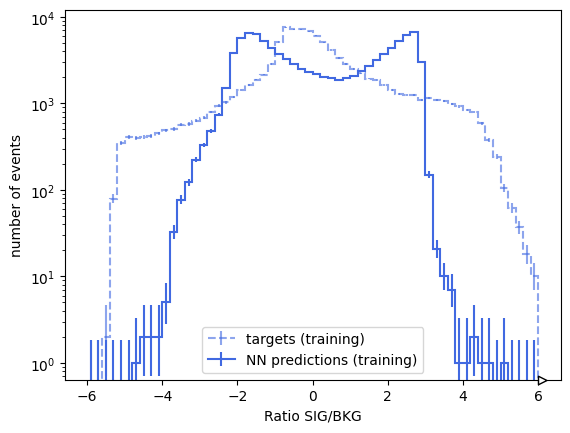

In [ ]:
BINS = 60

bounds = [-6,6]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(np.log(predictions_train/(1-predictions_train)))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(np.log(targets_train/(1-targets_train)))

h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')


plt.xlabel(f'Ratio {component_names[COMPONENT_1]}/{component_names[COMPONENT_2]}')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

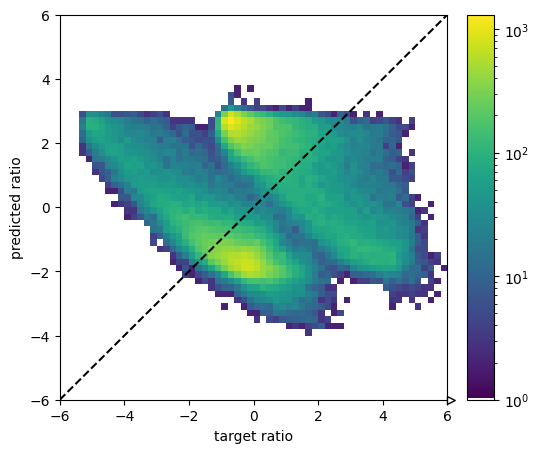

In [24]:
BINS=60

bounds = [-6,6]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='target ratio'),
    hist.axis.Regular(BINS, *bounds, name='predicted ratio')
)

h_calibration_train.fill(np.log(targets_train/(1-targets_train)), np.log(predictions_train/(1-predictions_train)))

#h_calibration_val = hist.Hist(
#    hist.axis.Regular(BINS, *bounds, name='target ratio'),
#    hist.axis.Regular(BINS, *bounds, name='predicted ratio')
#)

#h_calibration_val.fill(targets_val/(1-targets_val), predictions_val/(1-predictions_val))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_train.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

plt.show()

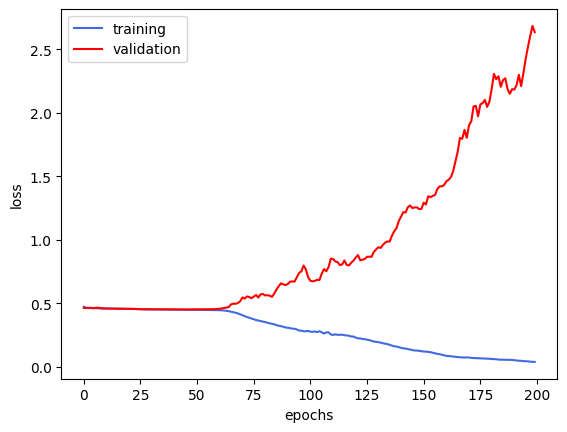

In [29]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
#plt.yscale('log')
plt.legend()
plt.show()